### Catboost base

CatBoost es probablemente la herramienta más potente para este dataset porque está diseñado específicamente para manejar variables categóricas sin necesidad de pre-procesamiento manual (como el One-Hot o el Frequency Encoding que se realizó para Random Forest).

Para este modelo base, se identificaron cuáles son las columnas categóricas y se las ingresó al modelo. CatBoost se encarga de los algoritmos de cuantización y combinación de categorías internamente, lo que suele reducir drásticamente el overfitting.

1_Carga del dataset train

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import cohen_kappa_score
from catboost import CatBoostClassifier

# 1. Cargar los datos
df = pd.read_csv('C:/Users/GWF/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/train/train.csv')
# Mostrar el dataset
df.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


Eliminación de variables e identificacón de variables categóricas

In [6]:
# 2. Eliminar variables de identidad y texto (Leakage y ruido)
# Mantenemos el mismo criterio que el Random Forest para que la comparación sea justa
columnas_a_eliminar = ['PetID', 'RescuerID', 'Name', 'Description']
df = df.drop(columns=columnas_a_eliminar)

# 3. Identificar variables categóricas
# A diferencia de RF, aquí NO hacemos dummies ni frequency encoding.
# Simplemente listamos las columnas que son categorías.
cat_features = [
    'Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 
    'Color3', 'State', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health'
]
# Mostrar el dataset
df.head()

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
0,2,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,0,1.0,2
1,2,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,0,2.0,0
2,1,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,0,7.0,3
3,1,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,0,8.0,2
4,1,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,0,3.0,2


Separar en train y test de manera estratificada.

In [7]:
# 4. Definir Target (y) y Features (X)
y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

# 5. Separar en train y test (66% / 34%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.34, 
    random_state=42, 
    stratify=y
)
print(f"Datos cargados: {X_train.shape[0]} filas para entrenar y {X_test.shape[0]} para test.")

Datos cargados: 9895 filas para entrenar y 5098 para test.


#### Entrenamiento y test del modelo

In [8]:
# 6. Configurar el modelo CatBoost
# Usamos parámetros conservadores para un baseline sólido
cb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0  # Para que no llene la pantalla de logs
)

# 7. Validación Cruzada con StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kappa_scores = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Entrenar pasando el parámetro cat_features
    cb.fit(X_fold_train, y_fold_train, cat_features=cat_features)
    
    preds = cb.predict(X_fold_val)
    kappa = cohen_kappa_score(y_fold_val, preds, weights='quadratic')
    kappa_scores.append(kappa)

print(f"CatBoost QWK en CV (Media): {np.mean(kappa_scores):.4f}")

# 8. Evaluación final en Test
cb.fit(X_train, y_train, cat_features=cat_features)
test_preds = cb.predict(X_test)
test_kappa = cohen_kappa_score(y_test, test_preds, weights='quadratic')

print(f"CatBoost QWK en Test: {test_kappa:.4f}")

CatBoost QWK en CV (Media): 0.3492
CatBoost QWK en Test: 0.3179


#### Importancia de variables

C:\Users\GWF\AppData\Local\Temp\ipykernel_43672\3662960797.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


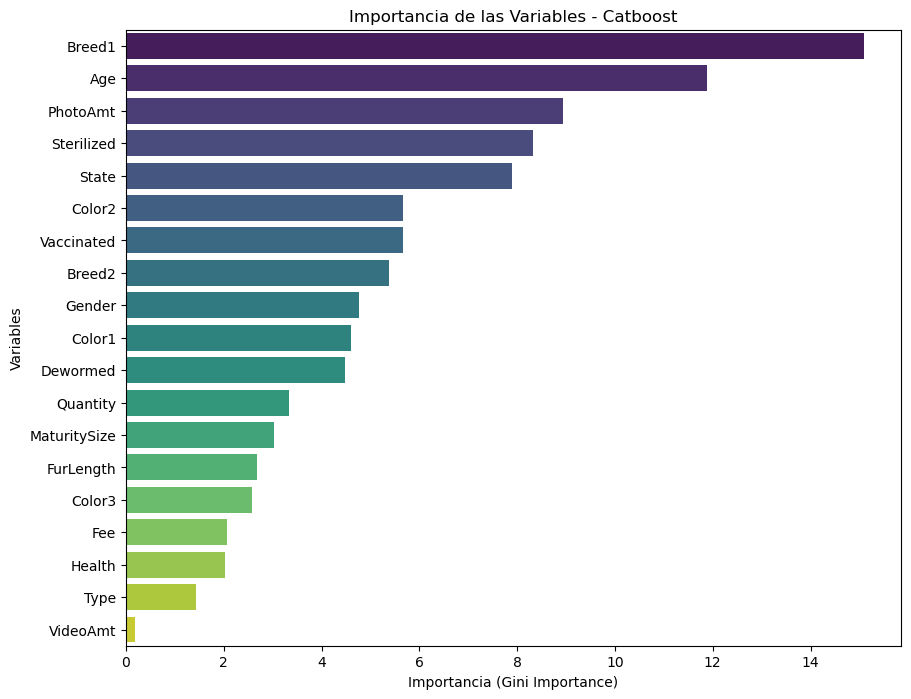

Top 5 variables más influyentes:
       Feature  Importance
2       Breed1   15.096644
1          Age   11.878036
18    PhotoAmt    8.936996
12  Sterilized    8.332431
16       State    7.900363


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener la importancia de las variables del modelo final
importances = cb.feature_importances_
feature_names = X_train.columns

# 2. Crear un DataFrame para facilitar el gráfico
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importancia de las Variables - Catboost')
plt.xlabel('Importancia (Gini Importance)')
plt.ylabel('Variables')
plt.show()

# 4. Mostrar las top 5 para análisis rápido
print("Top 5 variables más influyentes:")
print(feature_importance_df.head(5))